# Simulación en python para movimiento Broeniano
### Paola Figueroa
### 10/feb/2026

### Trayectoria individual

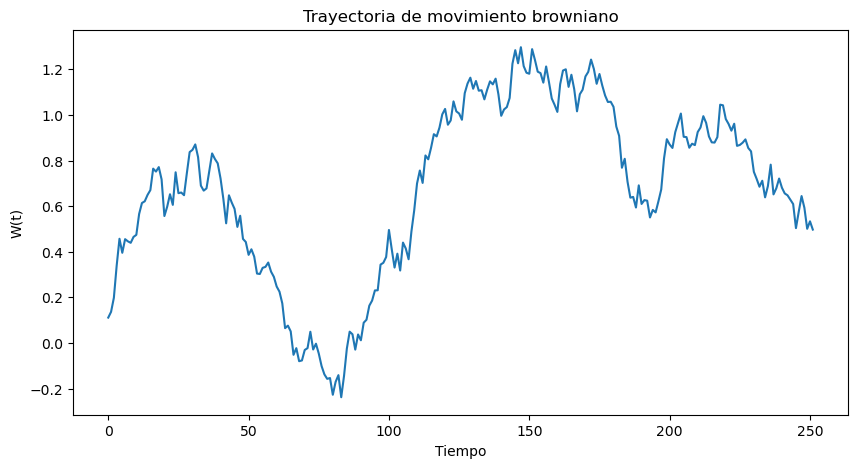

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

T = 1
n = 252
dt = T/n

increments = np.random.normal(0, np.sqrt(dt), size=n)
W = np.cumsum(increments)

plt.figure(figsize=(10,5))
plt.plot(W)
plt.title("Trayectoria de movimiento browniano")
plt.xlabel("Tiempo")
plt.ylabel("W(t)")
plt.show()

### Multiplices trayectorias

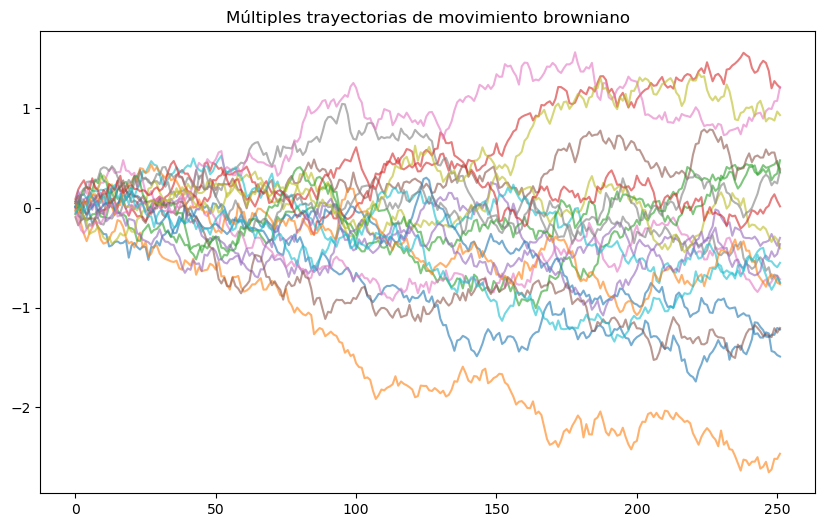

In [3]:
plt.figure(figsize=(10,6))

for _ in range(20):
    increments = np.random.normal(0, np.sqrt(dt), size=n)
    W = np.cumsum(increments)
    plt.plot(W, alpha=0.6)

plt.title("Múltiples trayectorias de movimiento browniano")
plt.show()

# la varianza crece de forma lineal conforme al tiempo

Las trayectorias divergen progresivamente conforme aumenta el tiempo, reflejando el crecimiento de la incertidumbre.

### Distribución en tiempo fijo


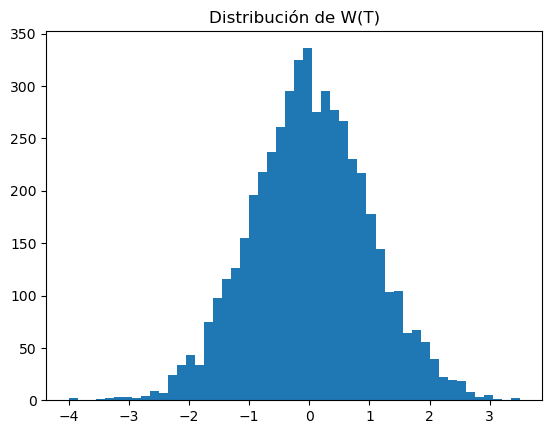

In [4]:
n_sim = 5000
final_values = []

for _ in range(n_sim):
    increments = np.random.normal(0, np.sqrt(dt), size=n)
    final_values.append(np.sum(increments))

plt.hist(final_values, bins=50)
plt.title("Distribución de W(T)")
plt.show()

La distribución resultante es aproximadamente normal con media cero y varianza proporcional al tiempo total.

## Activdad de clase

### Parte 1 — Simulación del proceso

1. Simular trayectorias de movimiento browniano estándar.

2. Utilizar al menos 5,000 simulaciones independientes.

3. Trabajar con los siguientes horizontes temporales:

   * T = 0.25
   * T = 0.5
   * T = 1
   * T = 2

4. Para cada horizonte temporal:

   * Discretizar el intervalo usando 252 pasos.
   * Generar incrementos normales con media cero.
   * Asegurar que la varianza escale correctamente con el tamaño del paso.
   * Calcular el valor final del proceso en el tiempo T.

El resultado debe ser un conjunto de valores finales para cada horizonte.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

n_sim=50000
n_pasos=252
tiempos= [0.25, 0.5, 1, 2]

resultados = {}
for i in range(len(tiempos)):
    dt=tiempos[i]/n_pasos
    increments= np.random.normal(0, np.sqrt(dt), size=(n_sim, n_pasos))
    W = np.cumsum(increments, axis=1)
    resultados[i]=W
resultados


{0: array([[ 6.35562019e-03, -1.09196633e-03, -3.23341737e-02, ...,
          2.51395476e-01,  2.60795468e-01,  2.99544185e-01],
        [-1.07048056e-03, -2.36077774e-04,  3.51345715e-02, ...,
          1.07511002e+00,  1.12633162e+00,  1.09959859e+00],
        [-1.43357567e-03,  2.67742956e-03,  3.68929210e-03, ...,
          4.53176078e-01,  4.42087075e-01,  4.14431903e-01],
        ...,
        [-5.99735605e-03, -9.32384138e-03, -8.57986611e-02, ...,
          5.62601814e-01,  5.49001082e-01,  5.29554866e-01],
        [-3.01573069e-02, -6.05192124e-02, -5.87819854e-02, ...,
         -5.12651189e-01, -5.37014652e-01, -4.91452456e-01],
        [-4.53429128e-02, -2.86591279e-02,  3.31273632e-02, ...,
          8.28474510e-01,  8.90663365e-01,  8.94037452e-01]]),
 1: array([[ 0.06458482,  0.11607214,  0.10190342, ...,  0.88620023,
          0.93921014,  0.96034905],
        [-0.05136974, -0.06444617, -0.02248063, ..., -0.54110198,
         -0.52875604, -0.51321728],
        [-0.0832986

### Parte 2 — Visualización

Construir una gráfica que muestre, en una misma figura:

* La distribución final del proceso para cada horizonte temporal.
* Utilizar histogramas superpuestos.
* Incluir leyenda y títulos adecuados.

La visualización debe permitir comparar claramente la dispersión de cada caso.

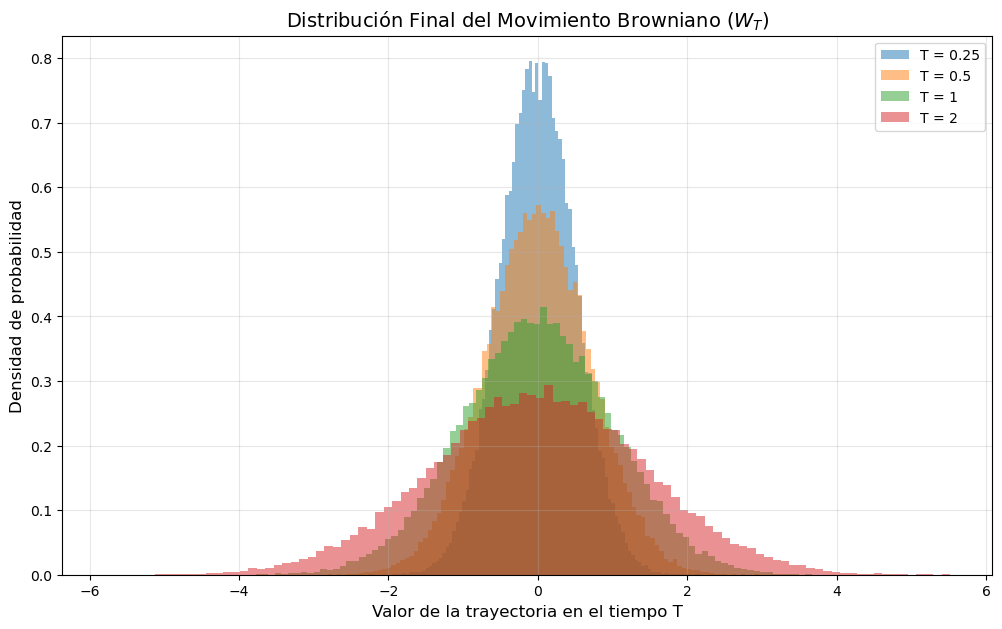

In [15]:
# gráfica de las distribuciones
plt.figure(figsize=(12, 7))

for i, T in enumerate(tiempos):
    valores_finales = resultados[i][:, -1]
    
    plt.hist(valores_finales, bins=100, alpha=0.5, 
             label=f'T = {T}', density=True) # density=True ayuda a comparar formas

plt.title('Distribución Final del Movimiento Browniano ($W_T$)', fontsize=14)
plt.xlabel('Valor de la trayectoria en el tiempo T', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Parte 3 — Análisis cuantitativo

Para cada horizonte temporal calcular:

* Media empírica
* Varianza empírica
* Desviación estándar empírica

Presentar los resultados en una tabla.

In [18]:
# Media, Varianza y Desviación Estándar
print(f"{'T':<10} | {'Media (Esperada 0)':<20} | {'Varianza (Esperada T)':<20} | {'Desviación Estándar':<20}")
print("-" * 75)
for i in range(len(tiempos)):
    mean_val = np.mean(resultados[i][:, -1])
    var_val = np.var(resultados[i][:, -1])
    desv_est_val = np.std(resultados[i][:, -1])
    print(f"{tiempos[i]:<10} | {mean_val:<20.4f} | {var_val:<20.4f} | {desv_est_val:<20.4f}")


T          | Media (Esperada 0)   | Varianza (Esperada T) | Desviación Estándar 
---------------------------------------------------------------------------
0.25       | -0.0011              | 0.2511               | 0.5011              
0.5        | -0.0018              | 0.5011               | 0.7079              
1          | -0.0035              | 1.0105               | 1.0052              
2          | 0.0118               | 1.9958               | 1.4127              


### Parte 4 — Preguntas de análisis

Responder de forma breve y precisa:

1. ¿Cómo cambia la dispersión de la distribución al aumentar el horizonte temporal?
-  El cambio en la dispersión indica que al aumentar el horizonte, la dispersión aumenta. La campana de la distribución se vuelve más ancha y baja, lo que indica una mayor incertidumbre sobre el valor final.

2. ¿La media del proceso depende del tiempo?
- La media del proceso es siempre 0, independientemente del tiempo porque la media de un movimiento Browniano es 0

3. ¿Qué relación observas entre la varianza y el tiempo?
- Existe una relación lineal directa. Mientras más tiempo, más aumenta la varianza.

4. Si el horizonte temporal se cuadruplica, ¿qué ocurre aproximadamente con la desviación estándar?
- La desviación estándar se duplica, ya que la desviación estándar es la raíz cuadrada del tiempo y la varianza de un movimiento browniano es T.

5. ¿Qué implicaciones tiene este comportamiento para el riesgo financiero a distintos horizontes?
- El riesgo crece con el horizonte temporal, pero lo hace a una tasa decreciente (sqrt de T). Esto implica que las inversiones a largo plazo tienen una mayor exposición a movimientos extremos de precios, lo que requiere mayores reservas para cubrir posibles pérdidas.